In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier


In [5]:
# Load the dataset
df = pd.read_csv(r"C:\Users\henri\Downloads\creditcard.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True)*100)
print(df.duplicated().sum())



   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [6]:
df = df.drop_duplicates()
print(df.duplicated().sum())
scaler = StandardScaler()


df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

0


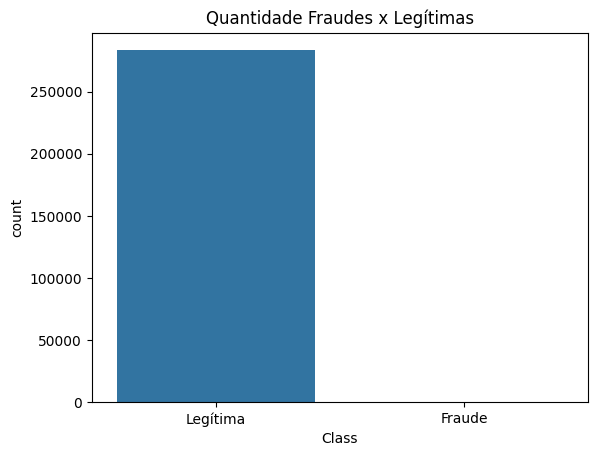

In [26]:
sns.countplot(x='Class', data=df)
plt.title('Quantidade Fraudes x Legítimas')
plt.xticks([0, 1], ['Legítima', 'Fraude'])
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

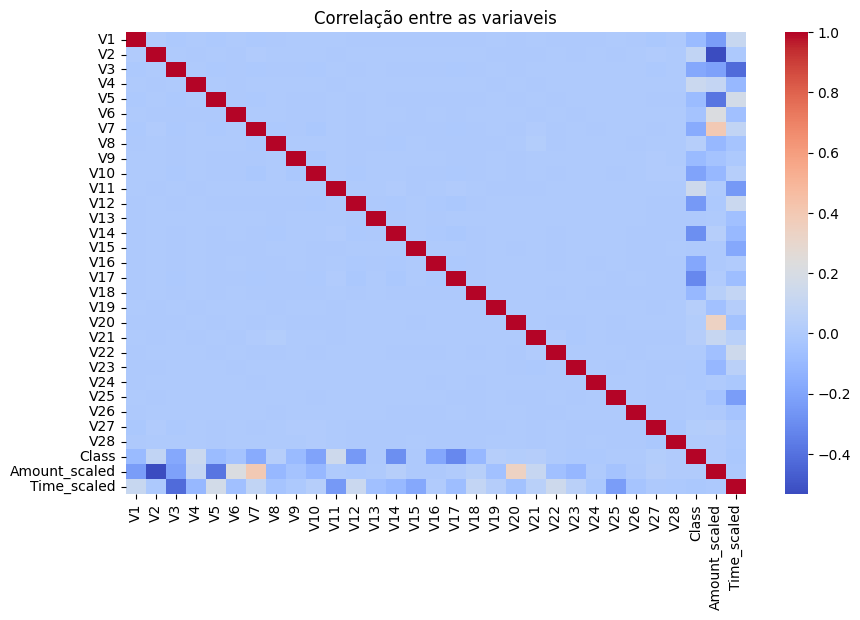

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlação entre as variaveis')
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

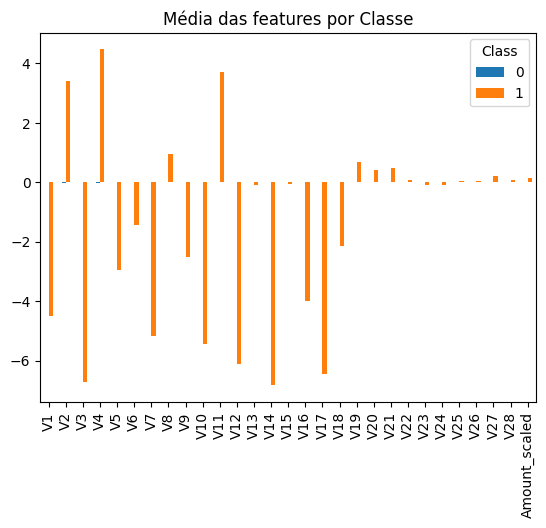

In [9]:
df.groupby('Class')[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28','Amount_scaled']].mean().T.plot(kind= 'bar')
plt.title('Média das features por Classe')
plt.savefig('media_features.png')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis = 1) # features
Y = df['Class'] #alvo

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42, stratify = Y)

In [11]:
modelo = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    random_state=42
)
modelo.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
print(modelo.class_weight)

balanced


In [13]:
Y_pred = modelo.predict(X_test)
print(Y_pred)

[0 0 0 ... 0 0 0]


In [14]:
from sklearn.metrics import classification_report
print (classification_report(Y_test,Y_pred, target_names=['Legítima', 'Fraude']))

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56651
      Fraude       0.99      0.72      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
import numpy as np
print(np.unique(Y_pred, return_counts=True))

(array([0, 1]), array([56677,    69]))


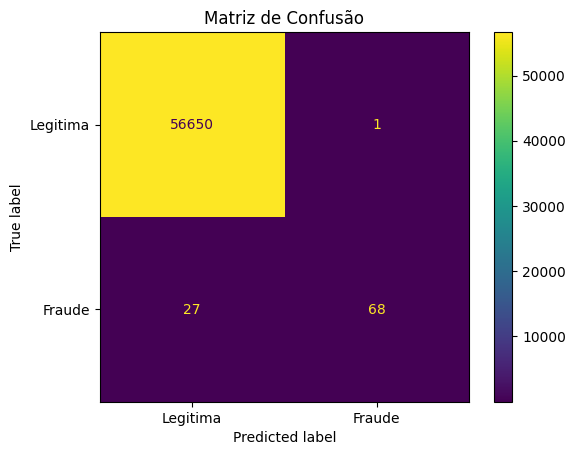

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred, display_labels=['Legitima', 'Fraude'])
plt.title('Matriz de Confusão')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

Y_prob = modelo.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
auc = roc_auc_score(Y_test, Y_prob)

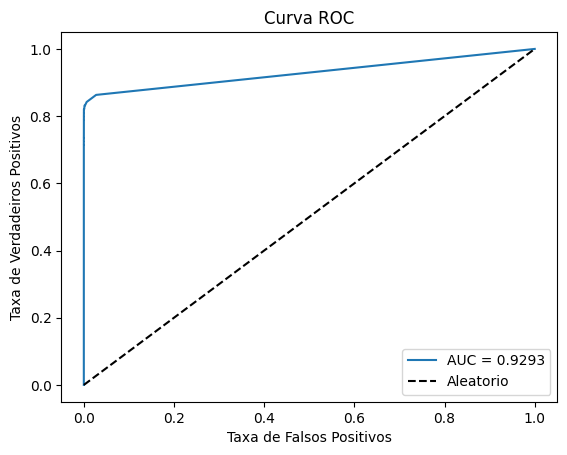

In [29]:
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], 'k--', label='Aleatorio')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

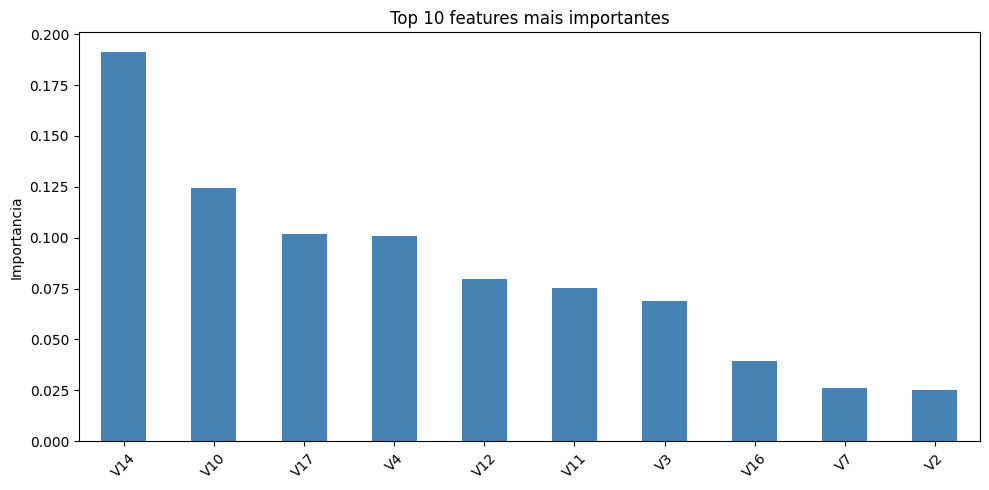

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns
importances = modelo.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

feat_imp.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Top 10 features mais importantes')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

O modelo identificou V14 como a feature mais discriminativa (~19% de importância), seguida por V10, V17 e V4. Juntas, as 4 principais features respondem por mais de 50% do poder preditivo do modelo.

## Conclusão

Este projeto teve como objetivo desenvolver um modelo de Machine Learning 
capaz de detectar transações bancárias fraudulentas a partir do dataset 
público de fraudes em cartão de crédito.

### Principais achados:

- O dataset apresentou forte desbalanceamento de classes, com apenas 0,17% 
  de transações fraudulentas, o que exigiu atenção especial na avaliação 
  do modelo.

- O algoritmo Random Forest foi selecionado por sua robustez e capacidade 
  de lidar com dados desbalanceados, sendo treinado com SMOTE para 
  balancear as classes durante o treinamento.

- O modelo atingiu AUC de 0.9293, demonstrando excelente capacidade 
  discriminativa entre transações legítimas e fraudulentas.

- A análise de Feature Importance revelou que V14 é a variável mais 
  relevante (~19%), seguida por V10, V17 e V4, que juntas respondem 
  por mais de 50% do poder preditivo do modelo.

- As features Amount e Time tiveram baixa importância, indicando que 
  o valor e o horário da transação isoladamente não são bons indicadores 
  de fraude.

### Próximos passos sugeridos:
- Testar outros algoritmos como XGBoost e LightGBM
- Explorar técnicas de threshold tuning para reduzir falsos negativos
- Implementar o modelo em uma API para uso em produção